# Human Action Classifier

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import re
import csv
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from joblib import dump
from extract import extract_descriptors, extract_points

In [2]:
# Use GPU (CUDA/MPS) if available
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


### 1. Data Loading

In [3]:
PREFIX = "0315-"
DESCRIPTION = "With Video Transformation (Horizontal Flip) and Empty Scene"
K = 1200
ACTIONS = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking", "empty"]
action_to_id = {a: i for i, a in enumerate(ACTIONS)}

VIDEO_ID_PATTERN = re.compile(r"person(?P<person>\d+)_(?P<action>[a-z]+)_d(?P<scene>\d+)")

def index_data(csv_file="data/info.csv", clips_root="data/transform"):
    samples = []

    with open(csv_file, newline="") as f:
        reader = csv.DictReader(f)

        for row in reader:
            video_id = row["video_id"]
            target_video = row["target_video"]
            action = row["label"]

            match = VIDEO_ID_PATTERN.match(video_id)
            if match is None or action not in action_to_id:
                continue

            clip_path = Path(clips_root) / target_video
            if not clip_path.exists():
                continue    # Skip missing clips (safe for partial generation)

            samples.append({
                "path": clip_path,
                "label": action_to_id[action],
                "action": action,
                "person": int(match.group("person")),
                "scene": int(match.group("scene")),
                "segment_id": int(row["segment_id"]),
                "video_id": video_id,
                "start_frame": int(row["start_frame"]),
                "end_frame": int(row["end_frame"]),
            })

    return samples

In [ ]:
# Import all data
samples = index_data()
print("Total:", Counter(s["action"] for s in samples))

# Train/validation/test split (70-30)
train_samples = [s for s in samples if s["person"] <= 18]
test_samples = [s for s in samples if s["person"] > 18]
print("Train:", len(train_samples), "Test:", len(test_samples))

Total: Counter({'jogging': 800, 'running': 800, 'walking': 800, 'empty': 800, 'handwaving': 796, 'boxing': 794, 'handclapping': 792})
Train: 3778 Validation: 904 Test: 900


### 2. Data Processing

In [5]:
def load_video(path, resize=(160, 120)):
    cap = cv2.VideoCapture(str(path))
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, resize)
        frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    video = np.stack(frames)   # (T, H, W)
    return torch.from_numpy(video)

def extract_all_descriptors(samples):
    # Extract descriptors for all samples
    all_desc = []

    for s in samples:
        video = load_video(s["path"])
        video = video.to(device)
        desc = extract_descriptors(video)
        all_desc.append(desc)

    return all_desc

def build_vocabulary(descriptors, K=400, max_samples=100_000):
    # Build vocabulary from pre-extracted training descriptors
    X = torch.cat(descriptors).cpu().numpy()

    if len(X) > max_samples:
        idx = np.random.choice(len(X), max_samples, replace=False)
        X = X[idx]

    kmeans = MiniBatchKMeans(n_clusters=K, batch_size=4096, random_state=0)
    kmeans.fit(X)
    return kmeans

In [ ]:
print("Extracting descriptors for all datasets...")
train_descriptors = extract_all_descriptors(train_samples)
test_descriptors = extract_all_descriptors(test_samples)

print("Learning vocabulary...")
kmeans = build_vocabulary(train_descriptors, K)
dump(kmeans, f"artifact/{PREFIX}kmeans_K{K}.joblib")

Extracting descriptors for all datasets...
Learning vocabulary...


['artifact/0315-kmeans_K1200.joblib']

### 3. Encode as Histogram

In [7]:
def encode_descriptors(desc, kmeans, K):
    # Encode pre-extracted descriptors as histogram
    if desc.numel() == 0:
        return torch.zeros(K)

    labels = kmeans.predict(desc.cpu().numpy())
    hist = np.bincount(labels, minlength=K).astype(np.float32)
    hist /= (hist.sum() + 1e-8)

    return torch.from_numpy(hist)

def build_dataset(samples, descriptors, kmeans, K):
    # Build dataset from pre-extracted descriptors
    X, y = [], []

    for i, s in enumerate(samples):
        # Encode descriptors
        hist = encode_descriptors(descriptors[i], kmeans, K)
        
        # Build dataset
        X.append(hist)
        y.append(s["label"])

    return torch.stack(X), torch.tensor(y)

In [ ]:
X_train, y_train = build_dataset(train_samples, train_descriptors, kmeans, K)
X_test, y_test = build_dataset(test_samples, test_descriptors, kmeans, K)

print("X_train", X_train.shape, "y_train", y_train.shape)
print("X_test", X_test.shape, "y_test", y_test.shape)

In [ ]:
save_dir = Path("artifact")
torch.save({
	"k": K,
	"actions": ACTIONS,
	"X_train": X_train, "y_train": y_train,
	"X_test": X_test, "y_test": y_test,
}, save_dir / f"{PREFIX}kth_features_K{K}.pt")

### 4. Data Visualization

In [18]:
def encode_video(video, kmeans, K):
    desc = extract_descriptors(video)

    if desc.numel() == 0:
        return torch.zeros(K)

    labels = kmeans.predict(desc.cpu().numpy())
    hist = np.bincount(labels, minlength=K).astype(np.float32)
    hist /= (hist.sum() + 1e-8)

    return torch.from_numpy(hist)

def visualize_histogram(hist, sample):
    plt.figure(figsize=(12, 4))
    plt.bar(range(K), hist.numpy())
    plt.title(f"Action: {sample['action']} | Person: {sample['person']} | Scene: {sample['scene']}")
    plt.xlabel("Visual Word Index")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"artifact/{PREFIX}histogram_action{sample['action']}_person{sample['person']}_scene{sample['scene']}.png", dpi=150)
    plt.show()

def visualize_descriptors(video, sample, sigma=1.5, tau=1.0, num_frames=2):
    # Extract features to get interest points
    points = extract_points(video, sigma, tau)
    print(f"Total descriptors detected: {len(points)}")
    if len(points) == 0:
        print("No descriptors detected in this video")
        return
    
    # Visualize descriptors on selected frames
    fig, axes = plt.subplots(1, min(num_frames, 2), figsize=(14, 5))
    if num_frames == 1:
        axes = [axes]
    
    # Select frames to visualize (spread across video)
    frame_indices = np.linspace(4, video.shape[0]-10, num_frames, dtype=int)
    
    for ax_idx, frame_idx in enumerate(frame_indices):
        frame = video[frame_idx].numpy()
        frame_display = (frame * 255).astype(np.uint8)
        
        # Get descriptors on this frame
        frame_points = points[points[:, 0] == frame_idx]
        
        ax = axes[ax_idx] if num_frames > 1 else axes[0]
        ax.imshow(frame_display, cmap='gray')
        
        # Draw circles at interest points
        if len(frame_points) > 0:
            for _, y, x in frame_points:
                circle = plt.Circle((x, y), 3, color='red', fill=False, linewidth=2)
                ax.add_patch(circle)
        
        ax.set_title(f"Frame {frame_idx} ({len(frame_points)} descriptors)")
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f"artifact/{PREFIX}descriptors_action{sample['action']}_person{sample['person']}_scene{sample['scene']}.png", dpi=150)
    plt.show()


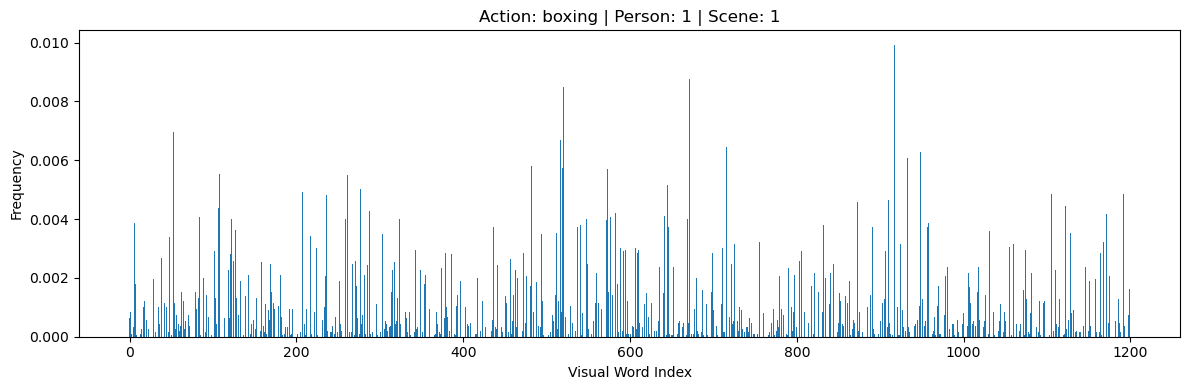

NameError: name 'extract_points' is not defined

In [19]:
# Get 1 id per sequence (the first)
sequenceIds = []
for actions in ACTIONS:
    seqId = next(i for i, kv in enumerate(train_samples) if kv['action'] == actions)
    sequenceIds.append(seqId)

# Visualize histogram and descriptor
for i in sequenceIds:
    sample = train_samples[i]
    video = load_video(sample["path"])
    video = video.to(device)
    hist = encode_video(video, kmeans, K)
    visualize_histogram(hist, sample)
    visualize_descriptors(video, sample, num_frames=2)

### 4. Train Classifier

In [10]:
class IntScaler():
    def __init__(self, scale=10000):
        self.scale = scale

    def fit_transform(self, data):
        return np.round(data * self.scale)
    
    def transform(self, data):
        return np.round(data * self.scale)

def train_svm(X, y):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.numpy())

    clf = LinearSVC(C=1.0, max_iter=5000)
    clf.fit(Xs, y.numpy())

    return clf, scaler

def train_gnb(X, y):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    clf = GaussianNB()
    clf.fit(Xs, y.numpy())
    
    return clf, scaler

def train_mnb(X, y):
    scaler = IntScaler()
    Xs = scaler.fit_transform(X.numpy())

    clf = MultinomialNB()
    clf.fit(Xs, y.numpy())
    
    return clf, scaler

def train_mlp(X, y):
    mlp = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=1000)
    mlp.fit(X, y.numpy())
    return mlp, None

In [11]:
print("Training classifier...")

clf_gnb, scaler_gnb = train_gnb(X_train, y_train)
clf_mnb, scaler_mnb = train_mnb(X_train, y_train)
clf_svm, scaler_svm = train_svm(X_train, y_train)
clf_mlp, scaler_mlp = train_mlp(X_train, y_train)

Training classifier...


### 5. Model Evaluation

In [12]:
def evaluate(clf, scaler, X, y):
    Xs = X if scaler is None else scaler.transform(X.numpy()) 
    y_pred = clf.predict(Xs)

    acc = balanced_accuracy_score(y.numpy(), y_pred)
    cm = confusion_matrix(y.numpy(), y_pred)

    return acc, cm

def save_results(K, actions, test_accs, filename="results.txt", description=""):
    with open(filename, 'w') as f:
        f.write("="*60 + "\n")
        f.write("MODEL PERFORMANCE SUMMARY\n")
        f.write("="*60 + "\n")
        f.write(f"Description: {description}\n")
        f.write(f"K: {K}\n")
        f.write(f"Actions: {', '.join(actions)}\n")
        f.write("-"*60 + "\n\n")
        f.write("\n")
        f.write("TEST ACCURACY\n")
        for model_name, acc in test_accs.items():
            f.write(f"  {model_name:20s}: {acc*100:6.2f}%\n")
        f.write("\n" + "="*60 + "\n")
    
    print(f"Results saved to {filename}")

In [13]:
print("---- Validation ----")

val_acc_gnb, _ = evaluate(clf_gnb, scaler_gnb, X_val, y_val)
print(f"Gaussian Naive Bayes val accuracy: {val_acc_gnb*100:.2f}%")
val_acc_mnb, _ = evaluate(clf_mnb, scaler_mnb, X_val, y_val)
print(f"Multinomial Naive Bayes val accuracy: {val_acc_mnb*100:.2f}%")
val_acc_svm, _ = evaluate(clf_svm, scaler_svm, X_val, y_val)
print(f"Linear SVM val accuracy: {val_acc_svm*100:.2f}%")
val_acc_mlp, _ = evaluate(clf_mlp, scaler_mlp, X_val, y_val)
print(f"Multilayer Perceptron val accuracy: {val_acc_mlp*100:.2f}%")

---- Validation ----
Gaussian Naive Bayes val accuracy: 72.10%
Multinomial Naive Bayes val accuracy: 75.51%
Linear SVM val accuracy: 80.44%
Multilayer Perceptron val accuracy: 83.86%


In [14]:
print("---- Test ----")

test_acc_gnb, cm_gnb = evaluate(clf_gnb, scaler_gnb, X_test, y_test)
print(f"Gaussian Naive Bayes test accuracy: {test_acc_gnb*100:.2f}%")
test_acc_mnb, cm_mnb = evaluate(clf_mnb, scaler_mnb, X_test, y_test)
print(f"Multinomial Naive Bayes test accuracy: {test_acc_mnb*100:.2f}%")
test_acc_svm, cm_svm = evaluate(clf_svm, scaler_svm, X_test, y_test)
print(f"Linear SVM test accuracy: {test_acc_svm*100:.2f}%")
test_acc_mlp, cm_mlp = evaluate(clf_mlp, scaler_mlp, X_test, y_test)
print(f"Multilayer Perceptron test accuracy: {test_acc_mlp*100:.2f}%")

# Save all results
test_accs = { 'Gaussian NB': test_acc_gnb, 'Multinomial NB': test_acc_mnb, 'Linear SVM': test_acc_svm, 'Multilayer Perceptron': test_acc_mlp}
save_results(K, ACTIONS, test_accs, f"artifact/{PREFIX}results_K{K}.txt", description=DESCRIPTION)

---- Test ----
Gaussian Naive Bayes test accuracy: 70.29%
Multinomial Naive Bayes test accuracy: 73.99%
Linear SVM test accuracy: 73.18%
Multilayer Perceptron test accuracy: 78.67%
Results saved to artifact/0315-results_K1200.txt


=== Linear SVM Confusion Matrix ===
[[ 84  26   3   1   2   6   4]
 [  2  99   0   2   0   3  22]
 [  7   2 103   0   9   6   1]
 [  0   2   4  92  14  12   4]
 [  5   2   6  28  73   7   7]
 [  0   2  11   7   3 104   1]
 [  9   8   5   0   1   7 104]]


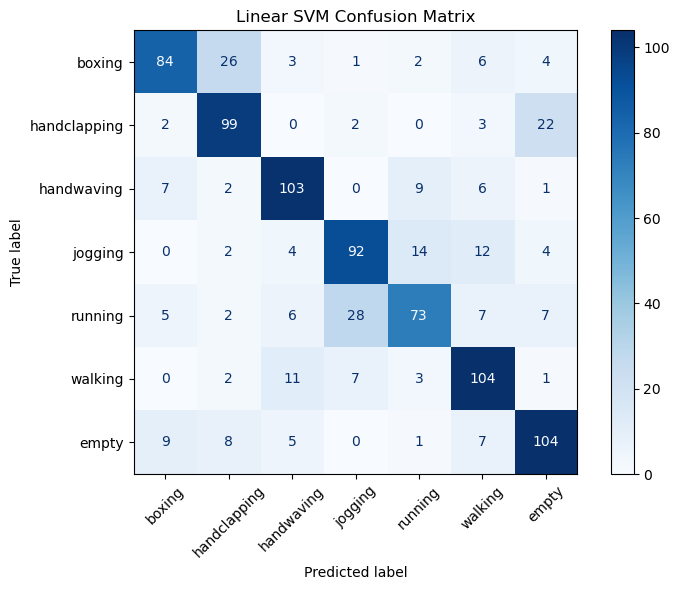

In [15]:
print("=== Linear SVM Confusion Matrix ===")
print(cm_svm)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=ACTIONS)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Linear SVM Confusion Matrix")
plt.tight_layout()
plt.show()